In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import warpSPHCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import warpSPHCore as sph
from warpSPHCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from warpSPHIntegrators.integration import *
from warpSPHCore import *

# This library
from warpSPH import *
from warpSPH.modules.timestep.compressible import computeTimestep

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/veldora/.cache/warp/1.15.0


# Sod Shock Tube (1D)

This notebook runs the classical 1D Sod shock tube Riemann problem with the initial states below.

Side | $p$ | $\\rho$ | $v$
---|---|---|---
Left | 1.0 | 1.0 | 0.0
Right | 0.1795 | 0.25 | 0.0

The expected solution contains the standard wave pattern: a left-going rarefaction, a contact discontinuity, and a right-going shock.

This notebook follows the same reusable structure used across all 15 compressible benchmark cases:

1. Configure imports and numeric precision.
2. Define case-specific physical parameters and initial-condition data.
3. Build domain, solver, and scheme configuration from shared builders.
4. Sample and initialize particles/state for the selected case.
5. Run the time integration loop with diagnostics and adaptive timestep control.
6. Export trajectory/state snapshots and generate image frames during the run.
7. Finalize outputs by writing final state data and rendering media artifacts (for example MP4/GIF).

Precision note: switching between single and double precision is controlled in the import/configuration block. Because precision is set when core modules/kernels are initialized, any precision change requires a kernel restart before re-running the notebook.

![](outputs/01-Sod_Shock_Tube.gif)

In [2]:
nx = 800
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)

samplingRatio = 4
smoothIC = True

initialStateDict = {
    'left_rho': leftState.rho,
    'left_pressure': leftState.p,
    'left_velocity': leftState.v,
    'right_rho': rightState.rho,
    'right_pressure': rightState.p,
    'right_velocity': rightState.v,
    'gamma': gamma,
    'nx': nx,
    'smoothIC': smoothIC,
    'samplingRatio': samplingRatio,
}

timeLimit = 0.15
L = 2
dim = 1
# n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

config, integrator = buildConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(4, dim),
    
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

scheme = CompressibleSPHScheme.CRKSPH

SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)

schemeConfig = SimulationConfig()
schemeConfig.gamma = gamma
schemeConfig.rho0 = leftState.rho

schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False

In [3]:
compSystem = buildSod1D(
    SimulationSystem, SimulationState,
    samplingRatio,
    leftState,
    rightState,
    gamma, config,
    True,
    
    adaptiveSupportScheme = schemeConfig.adaptiveSupportScheme,
)
kineticEnergy_ = 0.5 * (torch.linalg.norm(compSystem.state.velocities, dim = -1) **2 * compSystem.state.masses).sum()
thermalEnergy_ = (compSystem.state.internalEnergies * compSystem.state.masses).sum()
totalEnergy = kineticEnergy_ + thermalEnergy_


Module warpSPHCore.radiusSearch.compactHash.wp_index cb8e58c load on device 'cuda:0' took 4.79 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_hashCells 69952ab load on device 'cuda:0' took 2.67 ms  (cached)
Module warpSPHCore.coreOperations.wp_density 2312b34 load on device 'cuda:0' took 7.66 ms  (cached)
Module warpSPH.modules.adaptiveSupport.wp_psi e1bb97b load on device 'cuda:0' took 3.26 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_countNeighbors b9d3a6a load on device 'cuda:0' took 5.03 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_collectNeighbors ed2da4a load on device 'cuda:0' took 4.01 ms  (cached)
Module warpSPH.modules.adaptiveSupport.wp_psi0 b8a67bf load on device 'cuda:0' took 9.07 ms  (cached)
Initial internal energy: 0.7121 to  2.138


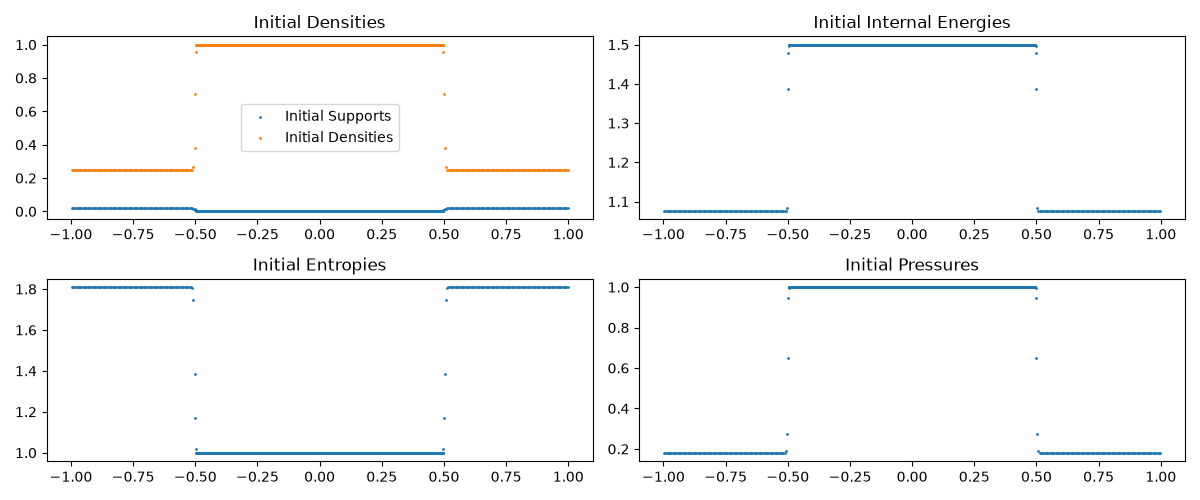

In [4]:
from warpSPH.util import plotToAxis1D
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
# plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.supports, title = 'Initial Supports')
plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.densities, title = 'Initial Densities')
# plotToAxis1D(axis[0,0], compSystem.state.positions, densities, title = 'Densities')
axis[0,0].legend()
plotToAxis1D(axis[1,0], compSystem.state.positions, compSystem.state.entropies, title = 'Initial Entropies')
plotToAxis1D(axis[0,1], compSystem.state.positions, compSystem.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], compSystem.state.positions, compSystem.state.pressures, title = 'Initial Pressures')
fig.tight_layout()
runningState = compSystem.initializeNewState()

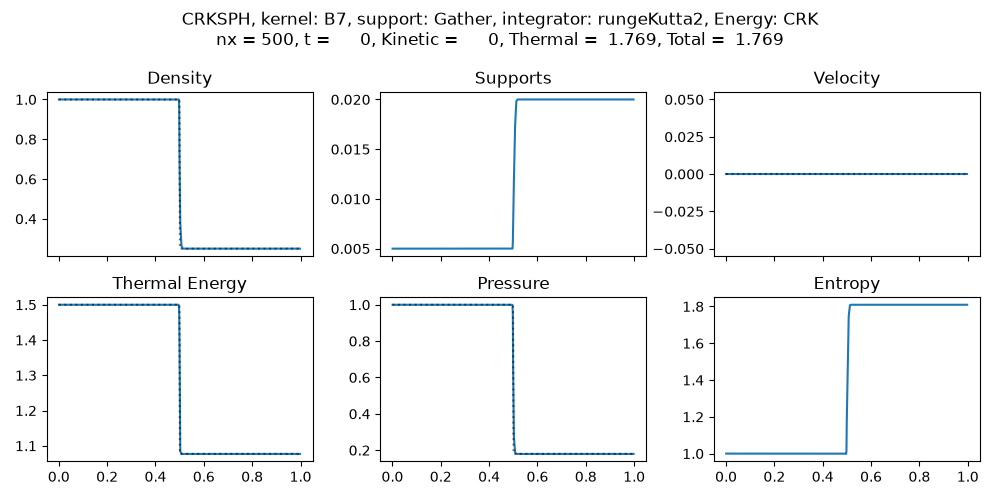

In [5]:
fig, axis = plotSod(runningState.state, config, schemeConfig, config.domain, gamma, leftState, rightState, plotReference = True, plotLabels = False, scatter = False, t_ = runningState.t)

In [6]:
caseName = '01-sodShockTube'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'kineticEnergy': kineticEnergy_,
    'thermalEnergy': thermalEnergy_,
    'totalEnergy': totalEnergy,
    'frame_num': 0,
}, **initialStateDict))

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
fig.savefig(f'{imagePath}/frame_{0:05d}.png')

In [7]:
t_limit = 0.15
# config.dt = 1e-4
nSteps = int(t_limit / config.dt)


print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 54

trajectory = []
runningState = compSystem.initializeNewState()
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    # begin = torch.cuda.Event(enable_timing=True)
    # end = torch.cuda.Event(enable_timing=True)
    # begin.record()
    # print(f"Step {i+1}/{nSteps}, time: {runningState.t:.4f}")
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,
        config = config,
        compParams = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    # end.record()
    # torch.cuda.synchronize()
    # elapsed_time_ms = begin.elapsed_time(end)

    runningState = result.state
    priorStep = result.stages[-1]

    kineticEnergy_ = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy_ = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy_ + thermalEnergy_

    tq.set_description(f"t: {runningState.t:.4f}, KE: {kineticEnergy_:.4f}, TE: {thermalEnergy_:.4f}, TE+KE: {totalEnergy:.4f}")
        
    trajectory.append((
        i,
        runningState.t,
        # elapsed_time_ms,
        kineticEnergy_.cpu().item(),
        thermalEnergy_.cpu().item(),
        totalEnergy.cpu().item(),
    ))
    if (i % 10 == 0 or i == nSteps - 1) and i > 0:
        for ax in axis.flatten():
            ax.clear()
        plotSod_(fig, axis, runningState.state, config, schemeConfig, config.domain, gamma, leftState, rightState, plotReference = True, plotLabels = False, scatter = True, t_ = runningState.t)
        fig.canvas.draw()
        fig.canvas.flush_events()
        fig.savefig(f'{imagePath}/frame_{i:05d}.png')

    if i % 50 == 0:
        exportSimulationSystem(exportPath, f'state_{i:04d}', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**initialStateDict, **{
            'kineticEnergy': kineticEnergy_,
            'thermalEnergy': thermalEnergy_,
            'totalEnergy': totalEnergy,
            'frame_num': i,
        }))

exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**initialStateDict, **{
    'kineticEnergy': kineticEnergy_,
    'thermalEnergy': thermalEnergy_,
    'totalEnergy': totalEnergy,
    'frame_num': i,
}))

Running with dt: 0.00030056745163165033, which gives nSteps: 499


  0%|          | 0/499 [00:00<?, ?it/s]

Module warpSPHCore.crk.crk_volume 22ee270 load on device 'cuda:0' took 6.23 ms  (cached)
Module warpSPHCore.crk.crk_moments ba5ede3 load on device 'cuda:0' took 6.57 ms  (cached)
Module warpSPHCore.crk.crk_density 0ffdccf load on device 'cuda:0' took 5.55 ms  (cached)
Module warpSPHCore.coreOperations.wp_gradient df5ad88 load on device 'cuda:0' took 8.85 ms  (cached)
Module warpSPH.modules.crk.accel b651419 load on device 'cuda:0' took 15.02 ms  (cached)
Module warpSPH.modules.crk.dudt 3124e4e load on device 'cuda:0' took 11.63 ms  (cached)
Module warpSPH.modules.compSPH.balance bf9cf70 load on device 'cuda:0' took 4.85 ms  (cached)


In [9]:
# Now run these commands:
# ffmpeg -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4
# ffmpeg -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png
# ffmpeg -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif

import shlex    
import subprocess
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
import shutil
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');